# Payments App Churn Prediction — Product Case Study

**Author:** Shuting
**Date:** May 2026

## Executive Summary
By deploying an optimised XGBoost model, the firm can reduce missed churners 
by 37% (from 30 to 19 per 1,409 test customers), saving 16,319 dollars in lost 
revenue net of retention costs — extrapolating to ~116,000 dollars per 10,000 customers.

*Note: This analysis uses the IBM Telco Customer Churn dataset as a proxy 
for a payments app context. Telco churn dynamics closely mirror payments 
app churn — both involve subscription-style recurring revenue, contract 
commitment levels, and feature adoption as retention signals.*

## Context and Dataset

This analysis uses the **IBM Telco Customer Churn dataset** (7,043 customers) 
as a proxy for a payments app context.

Telco churn dynamics closely mirror payments app churn — both involve:
- Subscription-style recurring revenue
- Contract commitment levels as a retention signal
- Feature adoption depth as a stickiness indicator
- High-value users being paradoxically more price-sensitive

**Feature mapping:**

| Telco Feature | Payments Equivalent |
|---------------|---------------------|
| Contract type | Subscription tier |
| Tenure | Months since signup |
| MonthlyCharges | Average monthly transaction value |
| TechSupport | Customer service contacts |
| PaymentMethod | Top-up method |
| StreamingTV/Movies | Premium feature adoption |

All product recommendations are framed in a payments app context based 
on these analogous relationships.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix,
                             precision_recall_curve)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.columns.tolist())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [2]:
# Class balance
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(2))

# Missing values
print(df.isnull().sum())

# Data types
print(df.dtypes)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovie

In [3]:
# Check what's wrong with TotalCharges
print(df["TotalCharges"].unique()[:20])

# Find rows where TotalCharges isn't a number
mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print(f"Rows with invalid TotalCharges: {mask.sum()}")
print(df[mask][["tenure", "MonthlyCharges", "TotalCharges"]].head())

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']
Rows with invalid TotalCharges: 11
      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             


In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
print(df["TotalCharges"].dtype)
print(df[df["tenure"] == 0]["TotalCharges"].head())

float64
488     0.0
753     0.0
936     0.0
1082    0.0
1340    0.0
Name: TotalCharges, dtype: float64


In [5]:
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean()
).reset_index()
contract_churn.columns = ["Contract", "churn_rate"]
contract_churn = contract_churn.sort_values("churn_rate", ascending=False)

In [6]:
print(contract_churn)

         Contract  churn_rate
0  Month-to-month    0.427097
1        One year    0.112695
2        Two year    0.028319


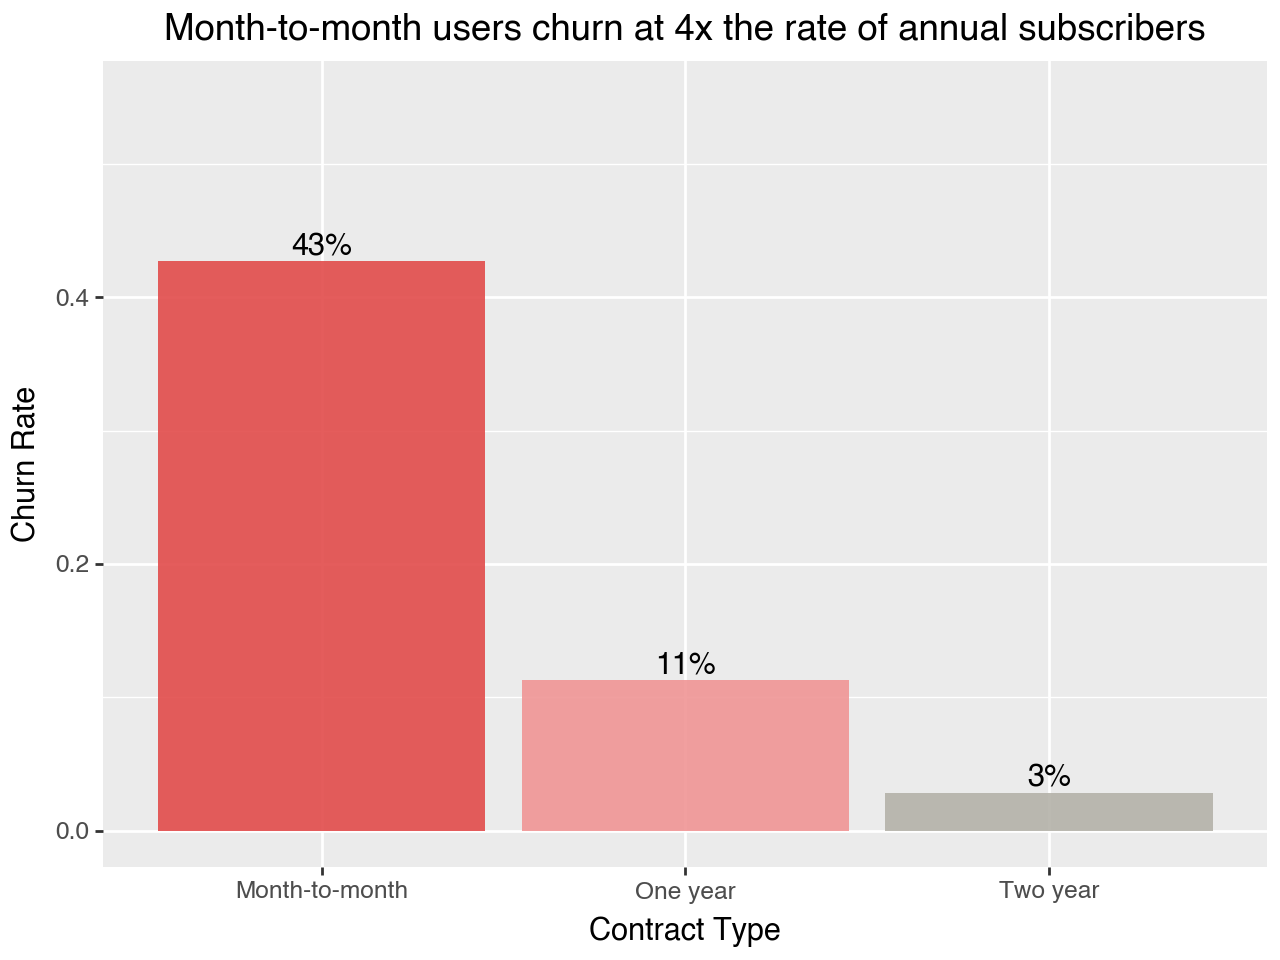

In [7]:
(ggplot(contract_churn, aes(x="reorder(Contract, -churn_rate)",
                            y="churn_rate",
                            fill="Contract"))
 + geom_bar(stat="identity", alpha=0.9)
 + geom_text(aes(label="churn_rate"), format_string="{:.0%}",
             va="bottom", size=11)
 + scale_fill_manual(values={
     "Month-to-month": "#E24B4A",
     "One year": "#F09595",
     "Two year": "#B4B2A9"})
 + labs(title="Month-to-month users churn at 4x the rate of annual subscribers",
        x="Contract Type",
        y="Churn Rate")
 + ylim(0,0.55)
 + theme(legend_position="none")
)

In [8]:
print("Min:", df["tenure"].min())
print("Max:", df["tenure"].max())
print("Mean:", df["tenure"].mean().round(1))
print("Median:", df["tenure"].median())
print()
print(df["tenure"].describe())

Min: 0
Max: 72
Mean: 32.4
Median: 29.0

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [9]:
print(df["tenure"].describe())

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [10]:
df["tenure_group"] = pd.cut(df["tenure"],
                            bins=[0, 12, 24, 48, 72],
                            labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"])

tenure_churn = df.groupby("tenure_group", observed=True)["Churn"].apply(
    lambda x: (x == "Yes").mean()
).reset_index()
tenure_churn.columns = ["tenure_group", "churn_rate"]
tenure_churn["label"] = tenure_churn["churn_rate"].apply(lambda x: f"{x:.0%}")


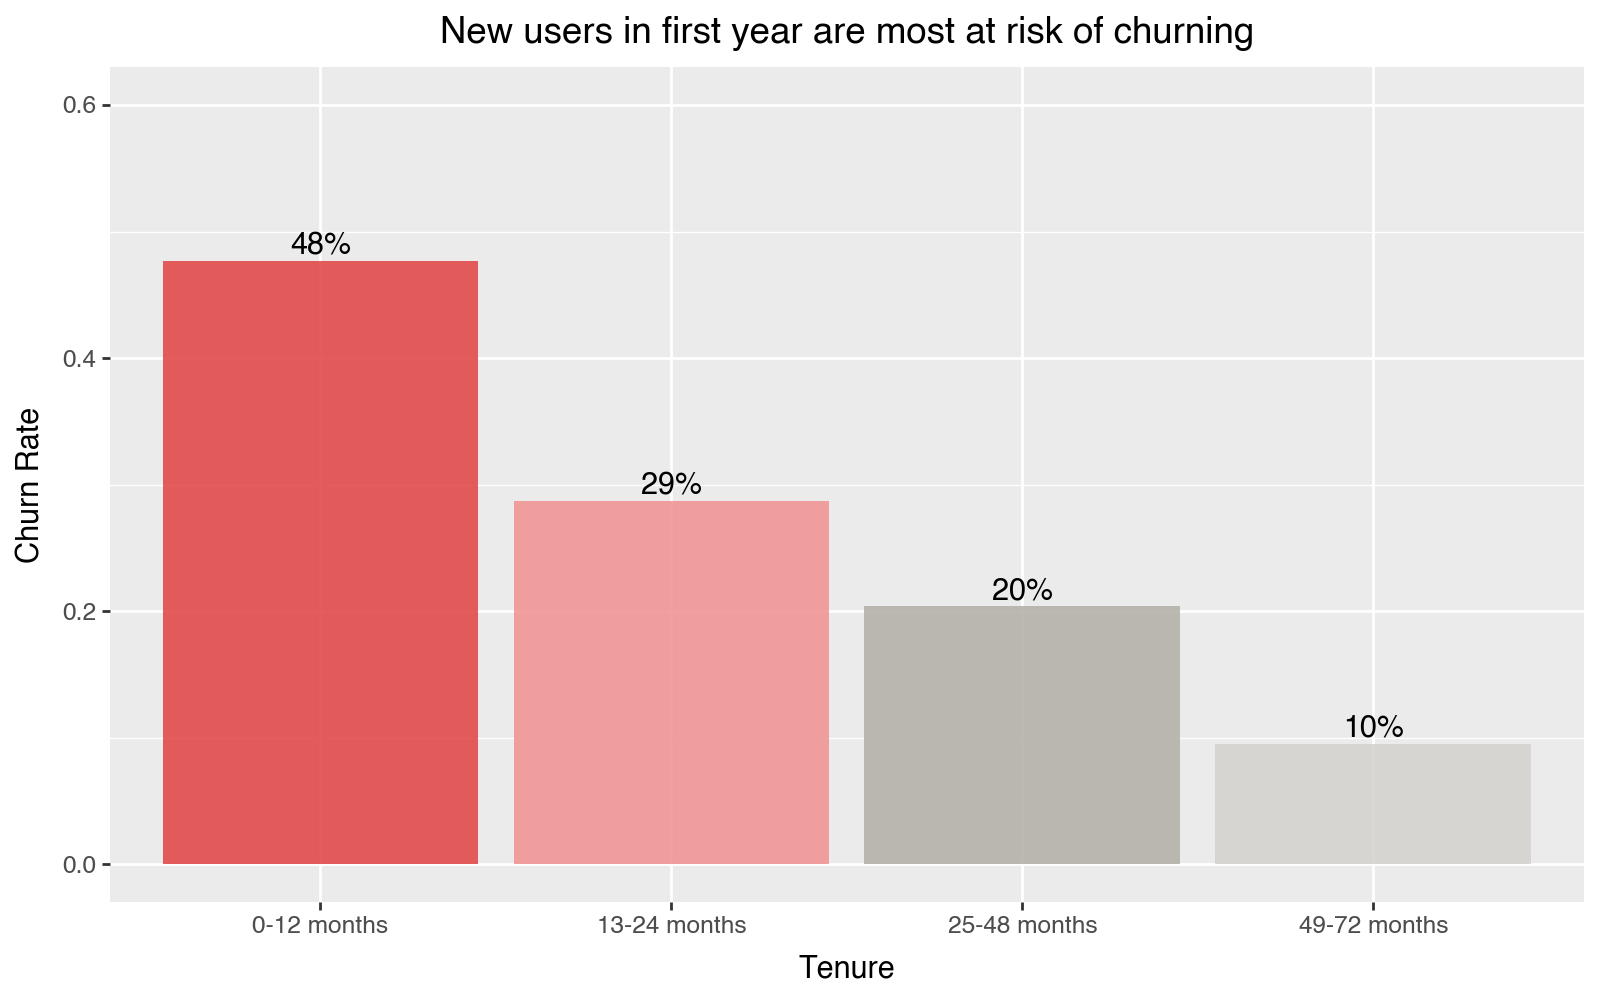

In [11]:
(ggplot(tenure_churn, aes(x="tenure_group", y="churn_rate", fill="tenure_group"))
 + geom_bar(stat="identity", alpha=0.9)
 + geom_text(aes(label="label"), va="bottom", size=11)
 + scale_fill_manual(values={
     "0-12 months": "#E24B4A",
     "13-24 months": "#F09595",
     "25-48 months": "#B4B2A9",
     "49-72 months": "#D4D3CF"})
 + labs(title="New users in first year are most at risk of churning",
        x="Tenure",
        y="Churn Rate")
 + ylim(0, 0.60)
 + theme(legend_position="none", figure_size=(8,5))
)

In [12]:
print(df["MonthlyCharges"].describe())

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


In [13]:
print(df["MonthlyCharges"].quantile([0.25, 0.50, 0.75]))


0.25    35.50
0.50    70.35
0.75    89.85
Name: MonthlyCharges, dtype: float64


In [14]:
df["charge_group"] = pd.cut(df["MonthlyCharges"],
                            bins=[0, 35, 70, 90, 120],
                            labels=["Low(<35)", "Mid(35-70)", "High(71-90)", "Premium(>90)"])
print(df["charge_group"].value_counts())

charge_group
High(71-90)     1844
Premium(>90)    1739
Low(<35)        1735
Mid(35-70)      1725
Name: count, dtype: int64


In [15]:
charge_churn = df.groupby("charge_group", observed=True)["Churn"].apply(
    lambda x: (x == "Yes").mean()
).reset_index()
charge_churn.columns = ["charge_group", "churn_rate"]


In [16]:
print(charge_churn)

   charge_group  churn_rate
0      Low(<35)    0.108934
1    Mid(35-70)    0.239420
2   High(71-90)    0.377983
3  Premium(>90)    0.327775


In [17]:
charge_churn["label"] = charge_churn["churn_rate"].apply(lambda x: f"{x:.0%}")
print(charge_churn)

   charge_group  churn_rate label
0      Low(<35)    0.108934   11%
1    Mid(35-70)    0.239420   24%
2   High(71-90)    0.377983   38%
3  Premium(>90)    0.327775   33%


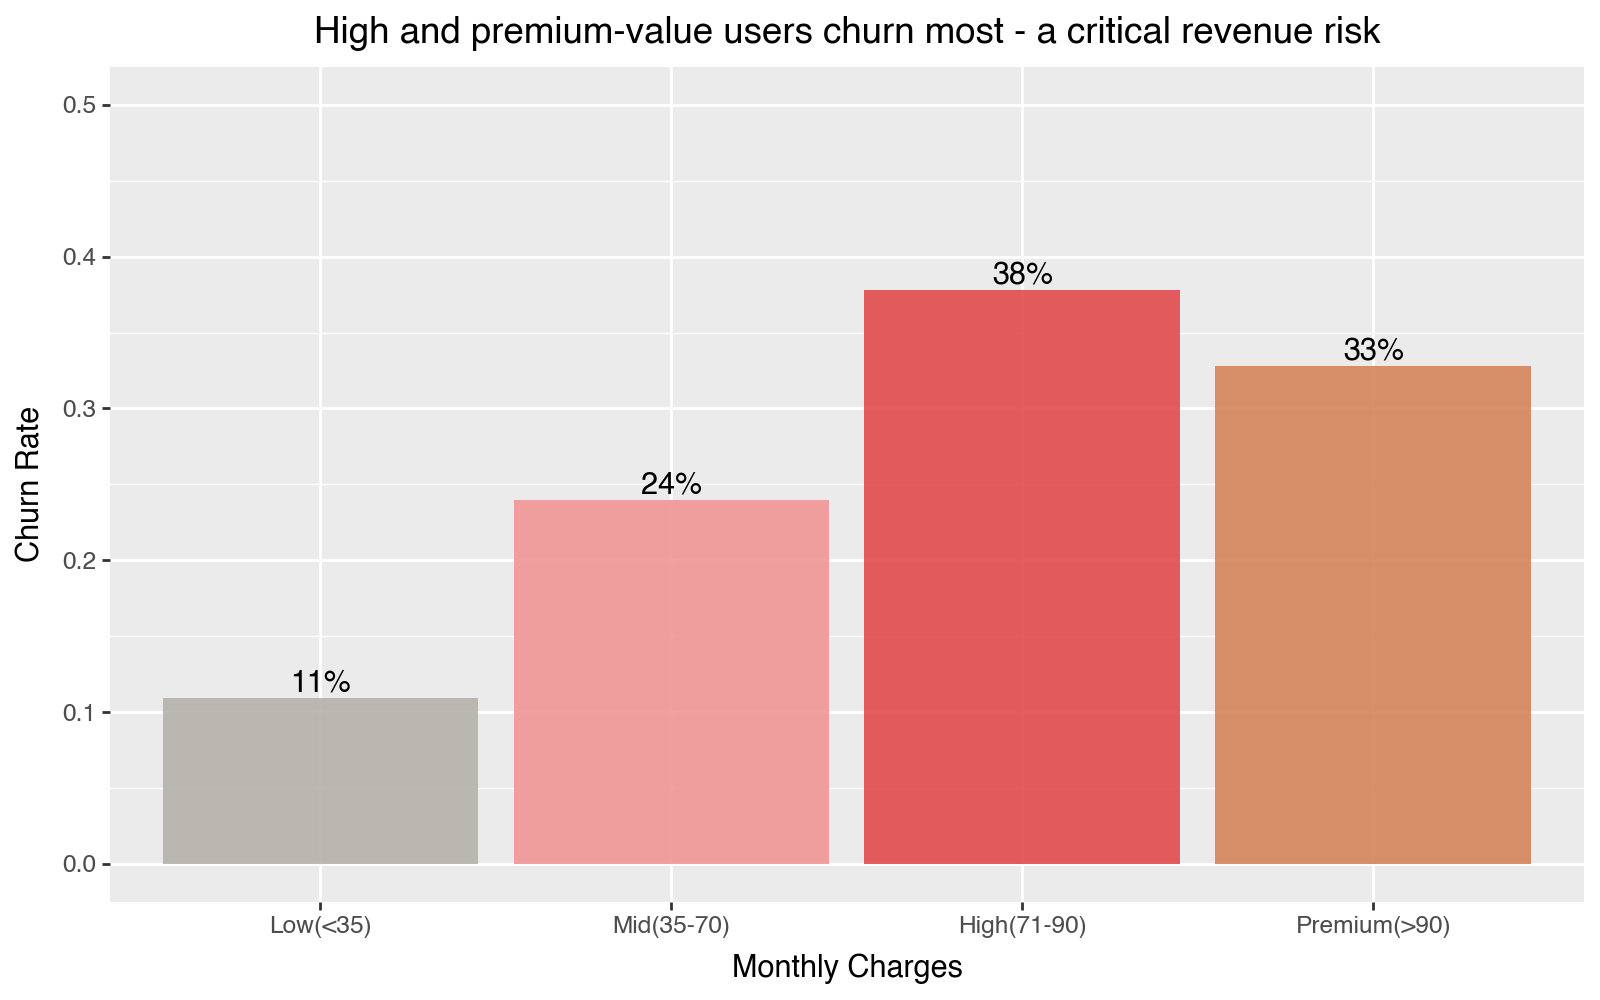

In [18]:
(ggplot(charge_churn, aes(x="charge_group", y="churn_rate", fill="charge_group"))
 + geom_bar(stat="identity", alpha=0.9)
 + geom_text(aes(label="label"), va="bottom", size=11)
 + scale_fill_manual(values={
     "Low(<35)": "#B4B2A9",
     "Mid(35-70)": "#F09595",
     "High(71-90)": "#E24B4A",
     "Premium(>90)": "#D4845A"})
 + labs(title="High and premium-value users churn most - a critical revenue risk",
        x="Monthly Charges",
        y="Churn Rate")
 + ylim(0, 0.50)
 + theme(legend_position="none", figure_size=(8,5))
)

In [19]:
# Encode target
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Drop customerID — not predictive
df = df.drop(columns=["customerID", "tenure_group", "charge_group"])

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df_encoded.astype(float)

print(f"Dataset shape: {df_encoded.shape}")
print(df_encoded.dtypes.value_counts())

Dataset shape: (7043, 31)
float64    31
Name: count, dtype: int64


In [20]:
pd.set_option('display.max_columns', None)
print(df_encoded.head(3))

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0            0.0     1.0           29.85         29.85    0.0          0.0   
1            0.0    34.0           56.95       1889.50    0.0          1.0   
2            0.0     2.0           53.85        108.15    1.0          1.0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0          1.0             0.0               0.0   
1          0.0             0.0               1.0   
2          0.0             0.0               1.0   

   MultipleLines_No phone service  MultipleLines_Yes  \
0                             1.0                0.0   
1                             0.0                0.0   
2                             0.0                0.0   

   InternetService_Fiber optic  InternetService_No  \
0                          0.0                 0.0   
1                          0.0                 0.0   
2                          0.0                 0.0   

   OnlineSecurity_No internet servic

In [21]:
redundant_cols = [
    "MultipleLines_No phone service",
    "OnlineSecurity_No internet service",
    "OnlineBackup_No internet service",
    "DeviceProtection_No internet service",
    "TechSupport_No internet service",
    "StreamingTV_No internet service",
    "StreamingMovies_No internet service"
]

df_encoded = df_encoded.drop(columns=redundant_cols)
print(f"Columns after removing redundant: {df_encoded.shape[1]}")

Columns after removing redundant: 24


In [22]:
pd.set_option('display.max_columns', None)
print(df_encoded.head(3))

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0            0.0     1.0           29.85         29.85    0.0          0.0   
1            0.0    34.0           56.95       1889.50    0.0          1.0   
2            0.0     2.0           53.85        108.15    1.0          1.0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0          1.0             0.0               0.0                0.0   
1          0.0             0.0               1.0                0.0   
2          0.0             0.0               1.0                0.0   

   InternetService_Fiber optic  InternetService_No  OnlineSecurity_Yes  \
0                          0.0                 0.0                 0.0   
1                          0.0                 0.0                 1.0   
2                          0.0                 0.0                 1.0   

   OnlineBackup_Yes  DeviceProtection_Yes  TechSupport_Yes  StreamingTV_Yes  \
0               1.0       

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Define features and target
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1,
                           max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Compare
results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, xgb_pred)
    ],
    "AUC": [
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
    ]
}).round(3)

print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall   AUC
      Random Forest     0.798      0.670   0.469 0.838
Logistic Regression     0.749      0.516   0.823 0.862
            XGBoost     0.814      0.686   0.550 0.862


In [24]:
# Get probabilities
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Find optimal threshold — maximise recall while keeping precision >= 40%
# Lower precision floor than credit risk because false positives are cheaper
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, xgb_proba)

viable = [(p, r, t) for p, r, t in 
          zip(precision_curve, recall_curve, thresholds) if p >= 0.4]
best = max(viable, key=lambda x: x[1])

print(f"Optimal threshold: {best[2]:.2f}")
print(f"Precision: {best[0]:.3f}")
print(f"Recall: {best[1]:.3f}")

# Apply optimised threshold
xgb_pred_optimised = (xgb_proba >= best[2]).astype(int)

print("\nConfusion Matrix (optimised):")
cm = confusion_matrix(y_test, xgb_pred_optimised)
print(cm)

print(f"\n--- Default vs Optimised ---")
print(f"Missed churners (default):   {cm[1][0] + (y_test==1).sum() - cm[1].sum()}")
print(f"Missed churners (optimised): {cm[1][0]}")

Optimal threshold: 0.10
Precision: 0.400
Recall: 0.949

Confusion Matrix (optimised):
[[505 531]
 [ 19 354]]

--- Default vs Optimised ---
Missed churners (default):   19
Missed churners (optimised): 19


In [25]:
# Split test set into high and low value segments
high_value_mask = X_test["MonthlyCharges"] > 70
low_value_mask = X_test["MonthlyCharges"] <= 70

# Get probabilities for each segment
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Apply different thresholds
pred_segmented = np.where(high_value_mask, 
                          (xgb_proba >= 0.10).astype(int),
                          (xgb_proba >= 0.30).astype(int))

# Evaluate
print("--- Segmented Threshold Model ---")
print("Precision:", round(precision_score(y_test, pred_segmented), 3))
print("Recall:", round(recall_score(y_test, pred_segmented), 3))
print("Accuracy:", round(accuracy_score(y_test, pred_segmented), 3))
print(confusion_matrix(y_test, pred_segmented))

# Compare retention offers sent
print(f"\nRetention offers sent (flat 0.10):     {(xgb_proba >= 0.10).sum()}")
print(f"Retention offers sent (segmented):     {pred_segmented.sum()}")
print(f"Offers saved:                          {(xgb_proba >= 0.10).sum() - pred_segmented.sum()}")

--- Segmented Threshold Model ---
Precision: 0.457
Recall: 0.874
Accuracy: 0.692
[[649 387]
 [ 47 326]]

Retention offers sent (flat 0.10):     890
Retention offers sent (segmented):     713
Offers saved:                          177


In [26]:
# Cost comparison
avg_monthly_charges = df["MonthlyCharges"].mean()
avg_tenure_remaining = 24  # assume 2 years remaining LTV
offer_cost = 5  # assume $5 per retention offer activated
activation_rate = 0.3  # assume 30% of offers activated

ltv_per_customer = avg_monthly_charges * avg_tenure_remaining

cost_saved = 177 * offer_cost * activation_rate
revenue_lost = 28 * ltv_per_customer

print(f"Average monthly charges: ${avg_monthly_charges:.2f}")
print(f"Estimated LTV per customer: ${ltv_per_customer:.2f}")
print(f"Cost saved from fewer offers: ${cost_saved:.2f}")
print(f"Revenue lost from missed churners: ${revenue_lost:.2f}")
print(f"Net impact: ${cost_saved - revenue_lost:.2f}")

Average monthly charges: $64.76
Estimated LTV per customer: $1554.28
Cost saved from fewer offers: $265.50
Revenue lost from missed churners: $43519.86
Net impact: $-43254.36


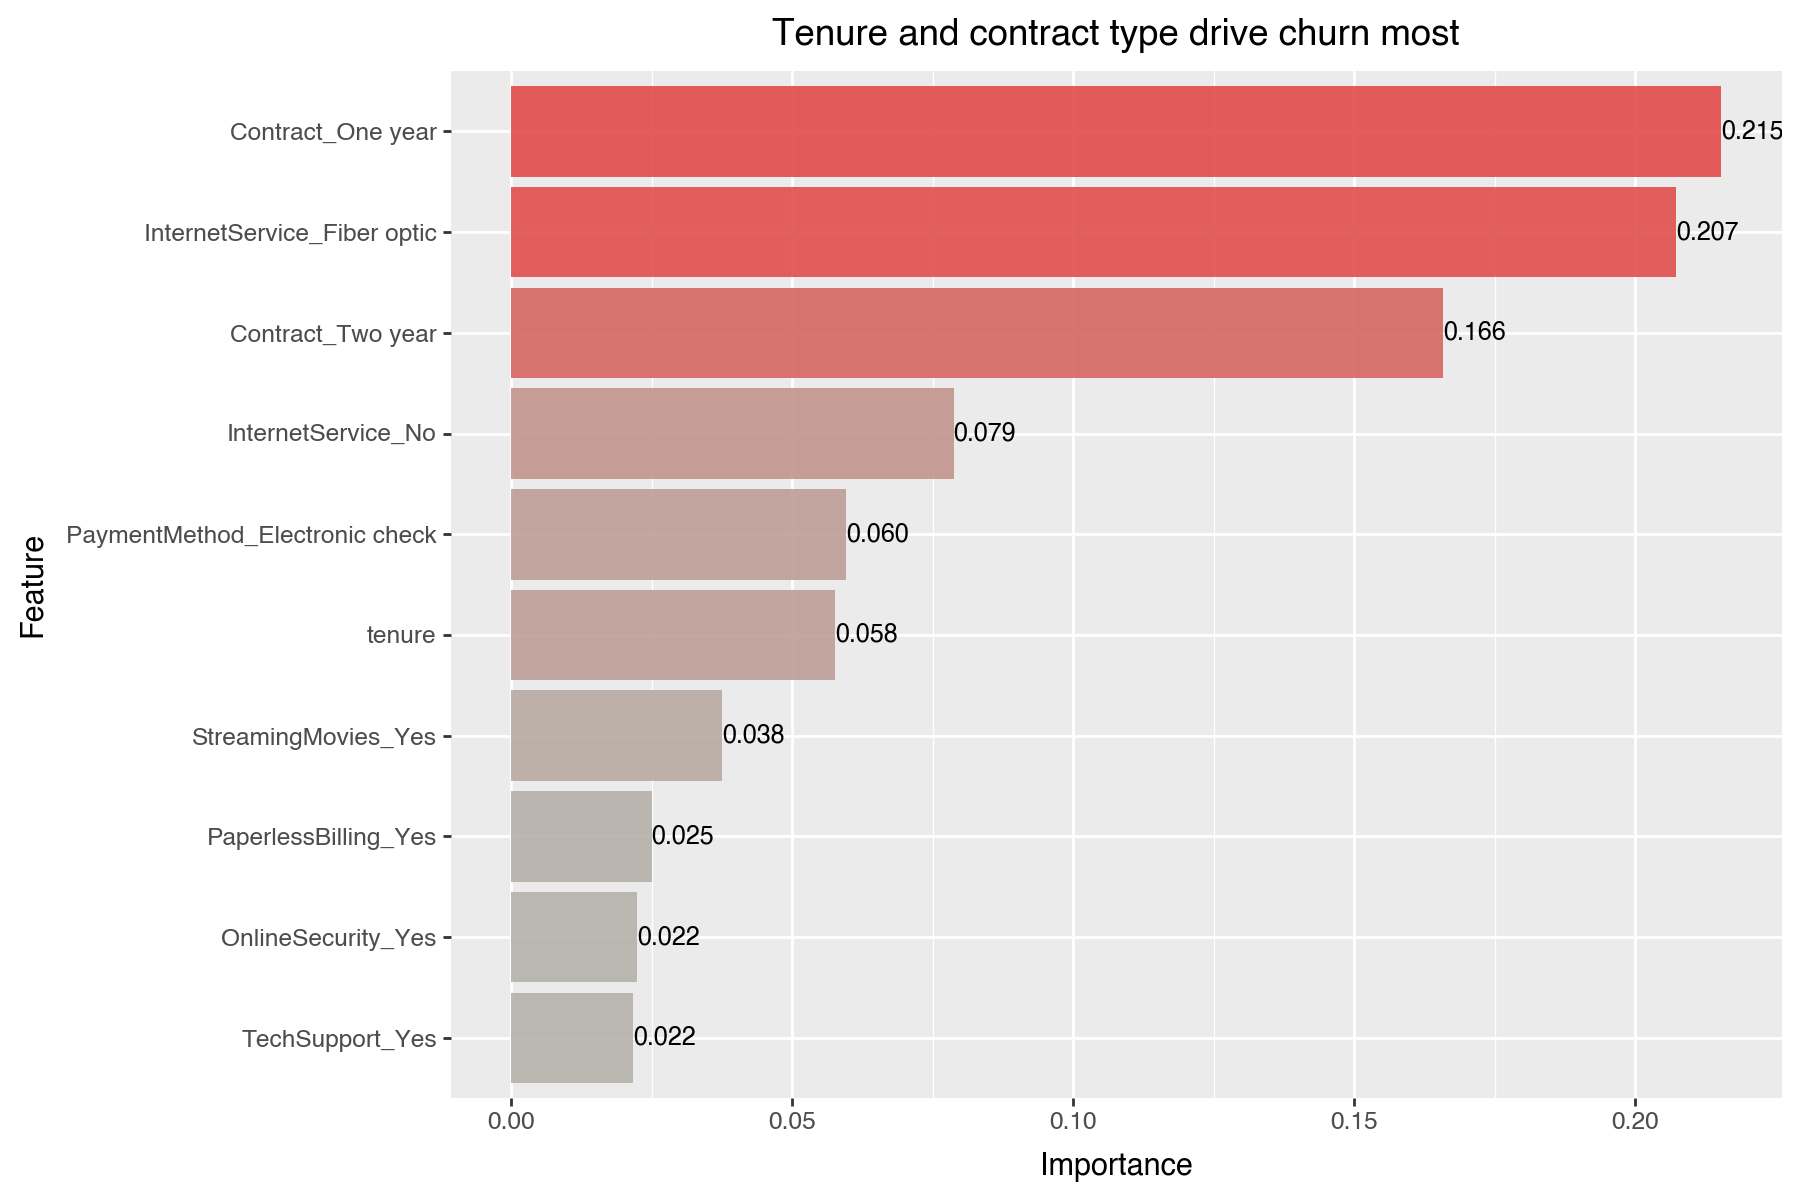

In [27]:
# Feature importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(10)

importance["label"] = importance["importance"].apply(lambda x: f"{x:.3f}")

(ggplot(importance, aes(x="reorder(feature, importance)", 
                         y="importance",
                         fill="importance"))
 + geom_bar(stat="identity", alpha=0.9)
 + geom_text(aes(label="label"), ha="left", size=9)
 + coord_flip()
 + scale_fill_gradient(low="#B4B2A9", high="#E24B4A")
 + labs(title="Tenure and contract type drive churn most",
        x="Feature",
        y="Importance")
 + theme(legend_position="none", figure_size=(9, 6))
)

In [28]:
# Business impact of optimised XGBoost vs default
avg_monthly = df["MonthlyCharges"].mean()
avg_tenure_remaining = 24  # assume 2 years remaining LTV
offer_cost = 5
activation_rate = 0.3

ltv_per_customer = avg_monthly * avg_tenure_remaining

# Default XGBoost (threshold 0.5)
default_missed = 30
default_false_alarms = 12  # from earlier confusion matrix

# Optimised XGBoost (threshold 0.10)
optimised_missed = 19
optimised_false_alarms = 531  # from confusion matrix

# Costs
default_cost = (default_missed * ltv_per_customer) + \
               (default_false_alarms * offer_cost * activation_rate)

optimised_cost = (optimised_missed * ltv_per_customer) + \
                 (optimised_false_alarms * offer_cost * activation_rate)

print(f"Average LTV per customer: ${ltv_per_customer:.2f}")
print()
print(f"--- Default XGBoost (threshold 0.50) ---")
print(f"Revenue lost from missed churners: ${default_missed * ltv_per_customer:,.2f}")
print(f"Cost of retention offers: ${default_false_alarms * offer_cost * activation_rate:,.2f}")
print(f"Total cost: ${default_cost:,.2f}")
print()
print(f"--- Optimised XGBoost (threshold 0.10) ---")
print(f"Revenue lost from missed churners: ${optimised_missed * ltv_per_customer:,.2f}")
print(f"Cost of retention offers: ${optimised_false_alarms * offer_cost * activation_rate:,.2f}")
print(f"Total cost: ${optimised_cost:,.2f}")
print()
print(f"Net improvement: ${default_cost - optimised_cost:,.2f}")
print(f"Extrapolated to 10,000 customers: ${(default_cost - optimised_cost) * (10000/len(y_test)):,.2f}")

Average LTV per customer: $1554.28

--- Default XGBoost (threshold 0.50) ---
Revenue lost from missed churners: $46,628.42
Cost of retention offers: $18.00
Total cost: $46,646.42

--- Optimised XGBoost (threshold 0.10) ---
Revenue lost from missed churners: $29,531.33
Cost of retention offers: $796.50
Total cost: $30,327.83

Net improvement: $16,318.59
Extrapolated to 10,000 customers: $115,816.80
